# Level 
This notebook checks that the sample test statistics has asynptotically the correct level

In [1]:
from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
import polars as pl

from gpy_test.config.covariance import CovarianceConfig
from gpy_test.covariance import covariance

from gpy_test import GPY
from gpy_test.result import GPYResult

In [2]:
# the complex gaussian time series will be ARMA(1,1) with the following parameters. 
ar = 0
ma = 0.8

# for the GPY test, we will use the following test functions
fs = [lambda x: x, lambda x: x**2]

In [3]:
# we will also need to provide the spectral density of the ARMA(1,1) process. It can also be computed
# from the sample time series.
def _ARMA_spectral_density(ar: float, ma: float) -> callable:
    ma_part = lambda nu: 1 + ma**2 + 2 * ma * np.cos(2 * np.pi * nu)
    ar_part = lambda nu: 1 / (1 + ar**2 - 2 * ar * np.cos(2 * np.pi * nu))
    return lambda nu: ar_part(nu) * ma_part(nu)

oracle_sd = _ARMA_spectral_density(ar, ma)

eig_range = (0, 10)

In [4]:
# for each (N,M) experiment we need to compute upfront the limit covariance matrix
N_range = np.arange(50, 500+50, 50)
M_range = np.arange(50, 500+50, 50)

# collect the various c values explored in the experiments
cs = sorted(set([M / N for N in N_range for M in M_range]))
print(len(cs))

# load the base config
d = {'integral_config': {'type_': 'dblquad',
  'n_points': None,
  'epsabs': 1e-1,
  'epsrel': 1e-1},
 'fixed_point_config': {'init_m_real': 1.0,
  'init_m_imag': 1.0,
  'max_steps': 1000,
  'tolerance': 1e-4},
 'contour_config_pair': ({'imag_height': 0.2,
   'real_slack': 0.2,
   'type_': 'circle'},
  {'imag_height': 0.1, 'real_slack': 0.1, 'type_': 'circle'}),
 'derivative_epsilon': 1e-08,
 'admissible_imag': 0.001,
 'n_jobs': -1,
 'verbose': True}
covariance_config = CovarianceConfig(**d)

# For each c, compute the associated limit covariance matrix
Covs = {}
for c in tqdm(cs):
    # compute the covariance
    Cov = covariance(
        covariance_config,
        fs,
        oracle_sd,
        eig_range,
        c,
    )
    Covs[c] = Cov

# dump the Covs to pickle (is long to compute)
import pickle

with open("Covs.pkl", "wb") as f:
    pickle.dump(Covs, f)

63


  0%|          | 0/63 [06:00<?, ?it/s]


KeyboardInterrupt: 

In [22]:
results = []
for N in N_range:
    for M in M_range: 
                
        real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
        imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
        y = real + 1j * imag
            
        Cov = Covs[M / N]
        gpy_result = GPY(y, fs, Cov)

        record = {'N': N, 'M': M, 'c': M / N, 'test_statistic': gpy_result.test_statistic, 'p_value': gpy_result.p_value}
        results.append(record)

df = pl.DataFrame(results)



100%|██████████| 3/3 [00:00<00:00, 1537.69it/s]


ValueError: Convergence issue: the limit covariance matrix is not definite non-negative: covariance=array([[-1.43471412e-06, -4.38021011e-04],
       [-4.38021011e-04, -2.25059385e-04]])

In [ ]:
Cov

In [21]:
# check that the sample test statistics follow the same covariance
from gpy_test import GPY
from gpy_test.result import GPYResult

from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm


# the complex gaussian time series will be ARMA(1,1) with the following parameters
c = 0.2
N = 100  # number of samples
M = int(c * N)  # number of time series


# for the GPY test, we will use the following test functions
fs = [lambda x: x, lambda x: x**2]

# load the base config
d =   {'integral_config': {'type_': 'dblquad','n_points': None,
  'epsabs': 1e-1,
  'epsrel': 1e-1},
 'fixed_point_config': {'init_m_real': 1.0,
  'init_m_imag': 1.0,
  'max_steps': 100,
  'tolerance': 0.01},
 'contour_config_pair': ({'imag_height': 0.2,
   'real_slack': 0.2,
   'type_': 'ellipse'},
  {'imag_height': 0.1, 'real_slack': 0.1, 'type_': 'ellipse'}),
 'derivative_epsilon': 1e-08,
 'admissible_imag': 0.001,
 'n_jobs': -1,
 'verbose': True}
base_covariance_config = CovarianceConfig(**d)


def run() -> GPYResult:
    real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag
    # Provide a dummy covariance matrix, it won't be used. Here we are just interested in
    # collecting samples of the test statistics to estimate their covariance
    # Cov = np.identity(len(fs))  
    return GPY(y, fs, covariance_config=base_covariance_config)


# Generate a large number of experiments
n_repeat = 100
results = Parallel(n_jobs=-1)(delayed(run)() for _ in tqdm(range(n_repeat)))

# we also need to know the range of the eigenvalues of the covariance matrix. For that we just use
# the range of the eigenvalues of the sample covariance matrix for one of the experiments
eig_range = np.min(0), np.max(3)

# show the empirical covariance of the test statistics
np.cov(np.array([result.lss for result in results]).T)

KeyboardInterrupt: 

In [ ]:
Cov = np.array([[0.8000802, 1.9203702], [1.9203702, 4.92975598]]) # limit one 
Cov = np.array([[0.8059963, 2.26430559], [2.26430559, 7.02958829]]) # empirical one 

[0.1,
 0.1111111111111111,
 0.125,
 0.14285714285714285,
 0.16666666666666666,
 0.2,
 0.2222222222222222,
 0.25,
 0.2857142857142857,
 0.3,
 0.3333333333333333,
 0.375,
 0.4,
 0.42857142857142855,
 0.4444444444444444,
 0.5,
 0.5555555555555556,
 0.5714285714285714,
 0.6,
 0.625,
 0.6666666666666666,
 0.7,
 0.7142857142857143,
 0.75,
 0.7777777777777778,
 0.8,
 0.8333333333333334,
 0.8571428571428571,
 0.875,
 0.8888888888888888,
 0.9,
 1.0,
 1.1111111111111112,
 1.125,
 1.1428571428571428,
 1.1666666666666667,
 1.2,
 1.25,
 1.2857142857142858,
 1.3333333333333333,
 1.4,
 1.4285714285714286,
 1.5,
 1.6,
 1.6666666666666667,
 1.75,
 1.8,
 2.0,
 2.25,
 2.3333333333333335,
 2.5,
 2.6666666666666665,
 3.0,
 3.3333333333333335,
 3.5,
 4.0,
 4.5,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0]

In [ ]:
def run(N, M) -> GPYResult:
    real = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    imag = arma_generate_sample([1, -ar], [1, ma], (N, M), scale=1 / np.sqrt(2))
    y = real + 1j * imag
    return GPY(y, fs, Cov)


# Generate a large number of experiments for various configurations
n_repeat = 1000


tasks = []
for N in N_range:
    for M in M_range:
        c = M / N
        Cov = Covs[c]
        task = {"N": N, "M": M}
        tasks.extend([task] * n_repeat)

results = Parallel(n_jobs=1)(delayed(run)(**task) for task in tqdm(tasks))

  0%|          | 0/9000 [00:00<?, ?it/s]

 71%|███████   | 6396/9000 [03:13<15:58,  2.72it/s] 

KeyboardInterrupt: 

In [ ]:
df = pl.DataFrame(
    [
        {"lss": res.lss, "p_value": res.p_value, "N": res.N, "M": res.M}
        for res in results
    ]
)

In [ ]:
# use 
df.with_columns(
    (pl.col("p_value") < 0.025 | pl.col("p_value") > 0.975).alias("false_positive")
).groupby("N", "M").mean()

Number of p-values outside the 0.025 and 0.975 levels: 26 and 29
Proportion of p-values outside the 0.025 and 0.975 levels: 0.026 and 0.029


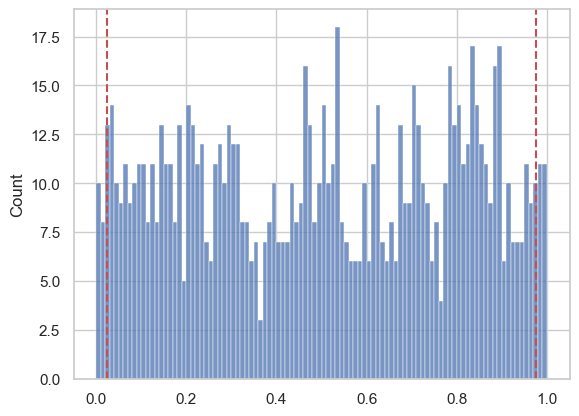

In [ ]:
# plot hist of p-values
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

p_values = [result.p_value for result in results]
sns.histplot(p_values, kde=False, bins=100)

# add on the graph a vertical line at the 0.05 level of a chi squared distribution with 2 degrees of freedom
plt.axvline(0.025, color="r", linestyle="--")
plt.axvline(0.975, color="r", linestyle="--")

# compute the number of p-values outside the 0.025 and 0.975 levels
n_below = np.sum(np.array(p_values) < 0.025)
n_above = np.sum(np.array(p_values) > 0.975)
print(f"Number of p-values outside the 0.025 and 0.975 levels: {n_below} and {n_above}")
print(
    f"Proportion of p-values outside the 0.025 and 0.975 levels: {n_below / n_repeat} and {n_above / n_repeat}"
)

Proportion of test statistics outside the 0.025 and 0.975 levels: 0.055


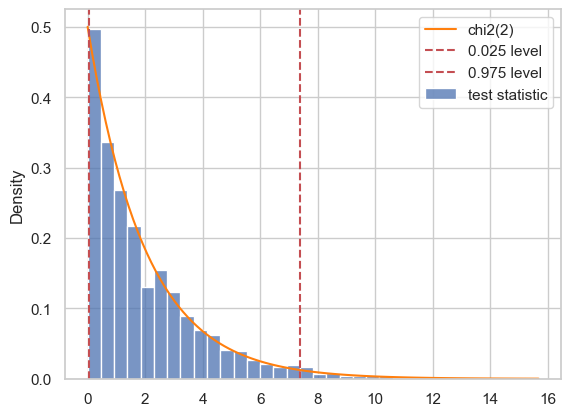

In [ ]:
# plot hist result.test_statistic against a chi2 distribution with 2 degrees of freedom

from scipy.stats import chi2

fig, ax = plt.subplots()
sns.histplot(
    [result.test_statistic for result in results],
    kde=False,
    ax=ax,
    stat="density",
    label="test statistic",
)
x = np.linspace(0, np.max([result.test_statistic for result in results]), 100)
ax.plot(x, chi2.pdf(x, 2), label="chi2(2)", color="tab:orange")


# add a vertical line at the 0.05 level
chi2_cutoff_1 = chi2.ppf(0.025, 2)
chi2_cutoff_2 = chi2.ppf(0.975, 2)
plt.axvline(chi2_cutoff_1, color="r", linestyle="--", label="0.025 level")
plt.axvline(chi2_cutoff_2, color="r", linestyle="--", label="0.975 level")

# print proportion of test statistics within the 0.025 and 0.975 levels
n_below_1 = np.sum(
    np.array([result.test_statistic for result in results]) < chi2_cutoff_1
)
n_below_2 = np.sum(
    np.array([result.test_statistic for result in results]) > chi2_cutoff_2
)
print(
    f"Proportion of test statistics outside the 0.025 and 0.975 levels: {(n_below_1 + n_below_2) / n_repeat}"
)

ax.legend()

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt


import sys

sys.path.append(
    "/Users/alexisrosuel/Library/Mobile Documents/com~apple~CloudDocs/recherche/CLT-LSS-coherence/src"
)

from clt_lss_coherence.data import DataGenConfig, generate_ARMA, ARMA_spectral_density
from clt_lss_coherence.GPY import (
    GridConfig,
    ContourConfig,
    GPYConfig,
    CovarianceConfig,
    FixedPointConfig,
    GPY,
    GPYResult,
)

import seaborn as sns

sns.set_style("whitegrid")